# Codigo Modelos Gradient Boosting

Es necesario hacer: pip install scikit-learn lightgbm xgboost catboost matplotlib pandas numpy

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# =======================================================================================
# 0. LECTURA DEL SUPERDATASET (de precios horarios de la electricidad, generacion y climatología)
# =======================================================================================
df_dummy = pd.read_csv('../../Dataset_Unificado/Dataset_Unificado1.csv', sep=';')
df_dummy['datetime'] = pd.to_datetime(df_dummy['datetime'])
df_dummy.set_index('datetime', inplace=True) 
# A partir de aquí, 'datetime' ya no es una columna

# =======================================================================================
# 1. PREPARACIÓN Y DIVISIÓN TEMPORAL
# =======================================================================================
X = df_dummy.drop(columns=['price'])
y = df_dummy['price']

# División cronológica estricta: entrenar con 2020-2023, validar con 2024 completo
X_train, X_test = X[X['year'] < 2024], X[X['year'] == 2024]
y_train, y_test = y[X['year'] < 2024], y[X['year'] == 2024]

# Eliminamos 'year' de los predictores porque los árboles no extrapolan bien hacia el futuro
X_train = X_train.drop(columns=['year'])
X_test = X_test.drop(columns=['year'])

# Variables categóricas temporales identificadas
cat_features = ['hour', 'month', 'dayofweek', 'is_weekend']
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')


# =======================================================================================
# 2. CONFIGURACIÓN LIGHTGBM (Anti-Overfitting)
# =======================================================================================
# Explicación de parámetros clave:
# - max_depth y num_leaves: Controlan el tamaño del árbol. Valores bajos evitan que memorice datos aislados.
# - min_data_in_leaf: Exige que cada conclusión matemática agrupe al menos 100 horas del histórico.
# - learning_rate bajo + n_estimators alto con early stopping: El modelo aprende de forma muy gradual.
# - reg_lambda: Regularización L2 para suavizar el impacto del precio del gas de 2022.
# - colsample_bytree: Cada árbol solo ve el 70% de las variables climáticas, evitando obsesionarse con una sola.

model_lgb = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.015,         # Aprendizaje lento y seguro
    max_depth=6,                 # Árboles poco profundos
    num_leaves=35,               # Límite de nodos terminales
    min_data_in_leaf=100,        # Evita hojas con pocas horas registradas
    reg_lambda=10.0,             # Penalización L2 estricta contra picos artificiales
    reg_alpha=2.0,               # Penalización L1 para descartar ruido climático
    colsample_bytree=0.7,        # Submuestreo de columnas por árbol
    subsample=0.8,               # Cada árbol usa solo el 80% de los días del histórico
    random_state=42,
    n_jobs=-1
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)] # Frena si el error en 2024 empieza a subir
)


# =======================================================================================
# 3. CONFIGURACIÓN XGBOOST (Anti-Overfitting)
# =======================================================================================
# Explicación de parámetros clave:
# - max_depth=5: Restringe drásticamente la estructura jerárquica del árbol (crecimiento por niveles).
# - min_child_weight: Equivalente al número de muestras en nodos. Si el peso es bajo, descarta la división.
# - gamma: Penalización por realizar cualquier división nueva en el árbol. Exige una ganancia de calidad alta.

model_xgb = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.015,
    max_depth=5,                 # Muy controlado para evitar memorizar curvas diarias exactas
    min_child_weight=50,         # Hojas con alta representación de datos
    gamma=5.0,                   # Penalización estricta por complejidad del árbol
    reg_lambda=15.0,             # Alta regularización L2 para absorber shocks de precios fósiles
    reg_alpha=2.0,               # Regularización L1
    colsample_bytree=0.7,        # Fuerza a buscar alternativas a las variables climáticas dominantes
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,     # Parámetro nativo de parada temprana en el constructor o fit
    enable_categorical=True
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)


# =======================================================================================
# 4. CONFIGURACIÓN CATBOOST (Anti-Overfitting)
# =======================================================================================
# Explicación de parámetros clave:
# - depth=6: Los árboles simétricos de CatBoost con profundidad 6 son sumamente estables.
# - l2_leaf_reg: Parámetro nativo de regularización L2.
# - rsm (Random Subspace Method): Equivalente a colsample_bytree, controla el porcentaje de variables por corte.

model_cat = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.02,
    depth=6,                     # Estructura simétrica robusta ante outliers climáticos
    l2_leaf_reg=12.0,            # Fuerte control de magnitudes en las hojas
    rsm=0.7,                     # Selecciona aleatoriamente subconjuntos de tus 27 columnas
    subsample=0.8,
    random_state=42,
    verbose=0,
    early_stopping_rounds=50
)

# Para CatBoost especificamos las columnas temporales que actúan como categorías de negocio
model_cat.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)


# =======================================================================================
# 5. EVALUACIÓN COMPARATIVA EN EL AÑO TEST (2024)
# =======================================================================================
modelos = {'LightGBM': model_lgb, 'XGBoost': model_xgb, 'CatBoost': model_cat}

print("\n=== RENDIMIENTO DE LOS MODELOS REGULARIZADOS EN EL AÑO TEST (2024) ===")
for nombre, modelo in modelos.items():
    preds = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    print(f"[{nombre}] MAE: {mae:.3f} | RMSE: {rmse:.3f}")



# =======================================================================================
# 6. EXPORTAR Y GUARDAR RESULTADOS (LOS 3 MODELOS)
# =======================================================================================
# Extraemos las predicciones de cada modelo
preds_lgb = model_lgb.predict(X_test)
preds_xgb = model_xgb.predict(X_test)
preds_cat = model_cat.predict(X_test)

# Creamos un nuevo dataframe para comparar la realidad vs la predicción
df_resultados = pd.DataFrame({
    'Precio_Real': y_test,
    'Prediccion_LightGBM': preds_lgb,
    'Diferencia_LightGBM': y_test - preds_lgb,
    'Prediccion_XGBoost': preds_xgb,
    'Diferencia_XGBoost': y_test - preds_xgb,
    'Prediccion_CatBoost': preds_cat,
    'Diferencia_CatBoost': y_test - preds_cat
}, index=y_test.index) # Usamos el índice de fechas que preparamos en el Paso 1 TODO!

# Añadimos variables temporales al dataframe de resultados para agrupar
df_resultados['hour'] = df_resultados.index.hour
df_resultados['month'] = df_resultados.index.month

# Calculamos el MAE promedio por hora del día para CatBoost
mae_por_hora = df_resultados.groupby('hour').apply(
    lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_CatBoost'])
)

print("=== MAE DE CATBOOST POR HORA DEL DÍA ===")
print(mae_por_hora)

# Guardamos los resultados en un archivo Excel o CSV para que puedas abrirlo
df_resultados.to_csv('predicciones_2024.csv')
print("\n¡Archivo 'predicciones_2024.csv' generado con éxito!")

print(f"Desviación Estándar Real (2024): {df_resultados['Precio_Real'].std():.2f}")
print(f"Desviación Estándar Predicha CatBoost: {df_resultados['Prediccion_CatBoost'].std():.2f}")

C:\Users\NITROPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087967 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6711
[LightGBM] [Info] Number of data points in the train set: 35064, number of used features: 31
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Info] Start training from score 100.084509

=== RENDIMIENTO DE LOS MODELOS REGULARIZADOS EN EL AÑO TEST (2024) ===
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] MAE: 29.850 | RMSE: 34.283
[XGBoost] MAE: 26.992 | RMSE: 31.526
[CatBoost] MA

### Visualización de las prediciones en una ventana de tiempo

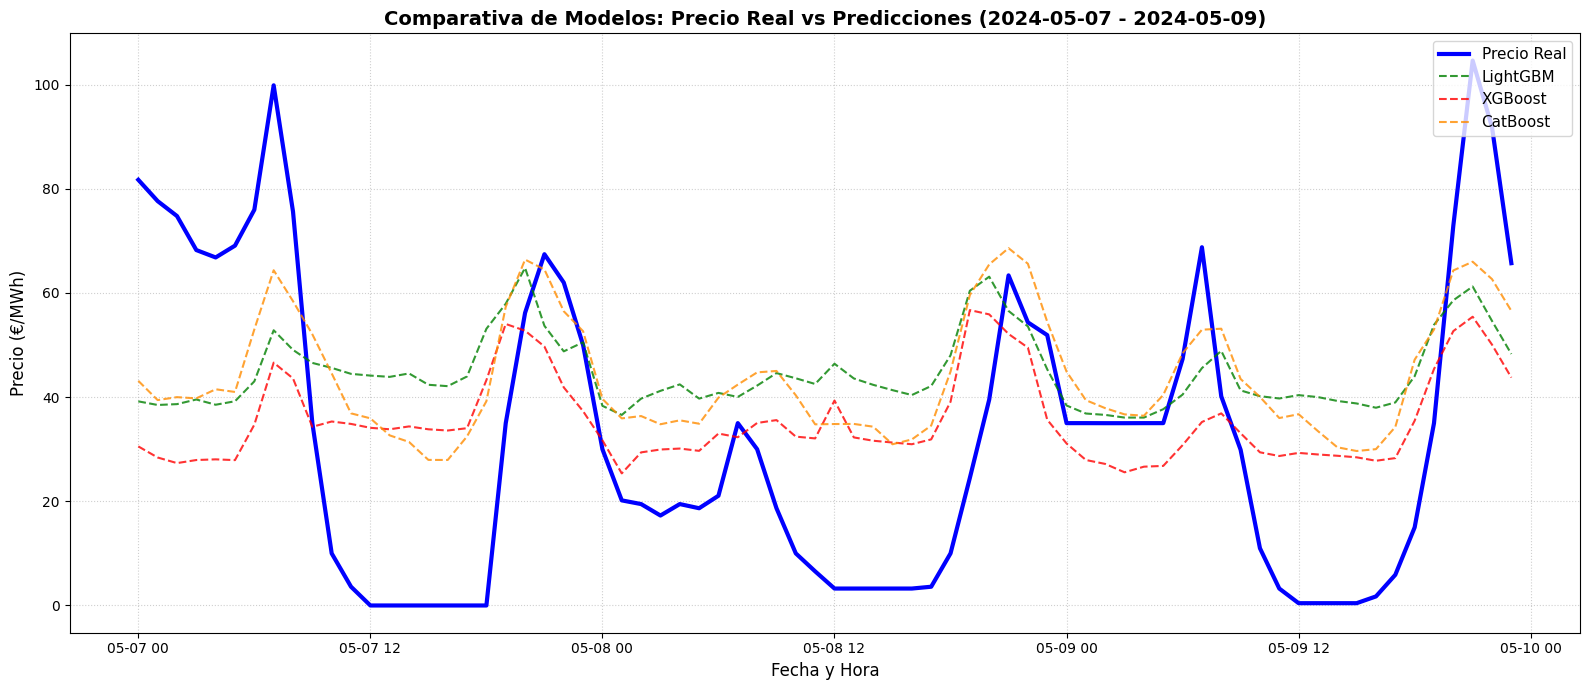

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 7. VISUALIZACIÓN DE RESULTADOS (LOS 3 MODELOS)
# =======================================================================================
# Filtramos un tramo corto (ej. primera quincena de enero de 2024)
df_resultados_csv = pd.read_csv('predicciones_2024.csv', index_col=0, parse_dates=True)
df_plot = df_resultados_csv.loc['2024-05-07':'2024-05-09'] #ejemplo: Cambiar a '2024-01-01:'2024-01-15' para ver solo la primera quincena

plt.figure(figsize=(16, 7))

# 1. Línea del Precio Real (Azul, continua y más gruesa para que destaque)
plt.plot(df_plot.index, df_plot['Precio_Real'], 
         label='Precio Real', color='blue', linewidth=3)

# 2. Línea LightGBM (Verde, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_LightGBM'], 
         label='LightGBM', color='green', linestyle='--', linewidth=1.5, alpha=0.8)

# 3. Línea XGBoost (Rojo, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_XGBoost'], 
         label='XGBoost', color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# 4. Línea CatBoost (Naranja, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_CatBoost'], 
         label='CatBoost', color='darkorange', linestyle='--', linewidth=1.5, alpha=0.8)

# Añadimos títulos y diseño
plt.title('Comparativa de Modelos: Precio Real vs Predicciones (' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Precio (€/MWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Guardamos y mostramos
plt.savefig('grafico_comparativa_3modelos_(' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')_2024.png', dpi=300)
plt.show()

### Tabla Horaria del Error 

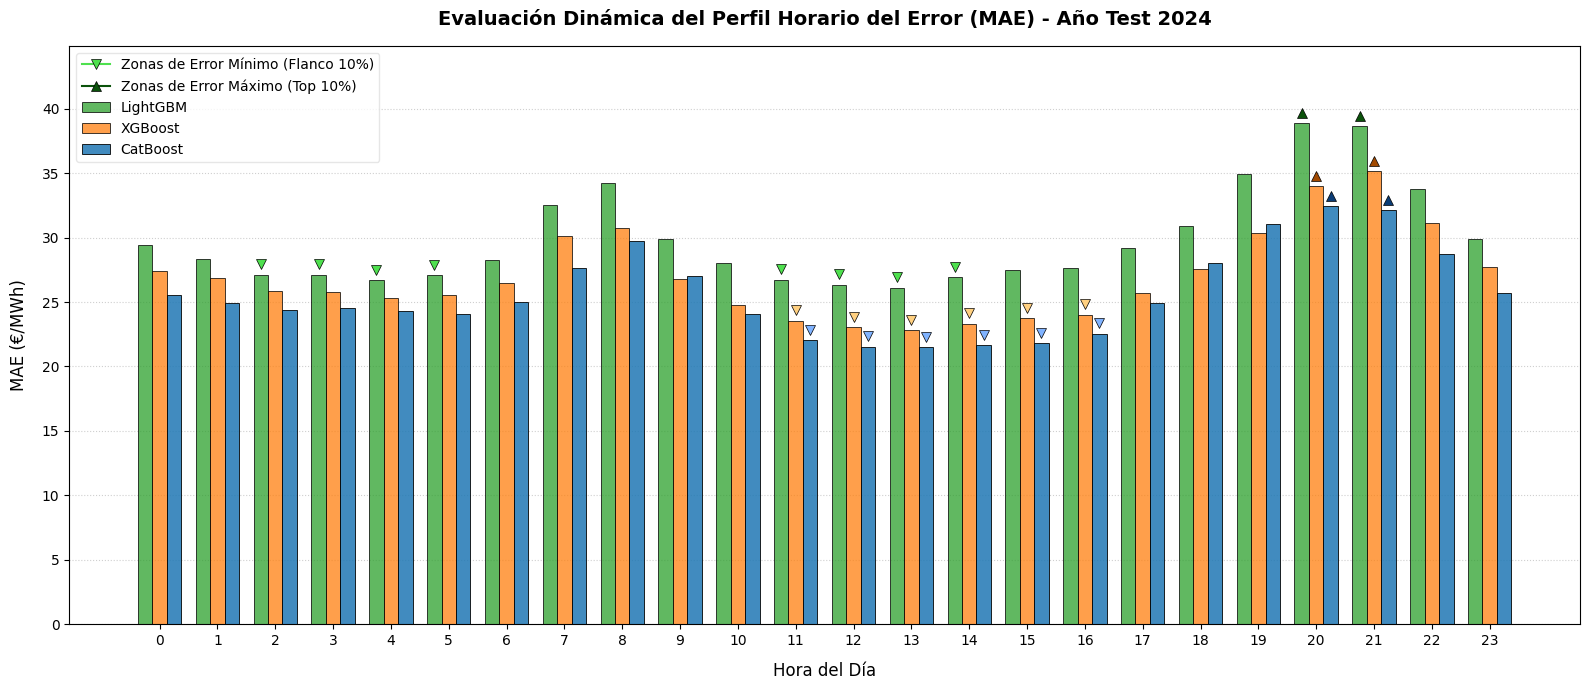

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 8. ANÁLISIS HORARIO COMPARATIVO DEL ERROR (LOS 3 MODELOS - DESDE CSV)
# =======================================================================================

# 1. Carga y cálculo dinámico de métricas por hora
df_resultados_csv = pd.read_csv('predicciones_2024.csv', index_col=0, parse_dates=True)
mae_lgb = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_LightGBM']))
mae_xgb = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_XGBoost']))
mae_cat = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_CatBoost']))

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.25

# 2. Dibujo de las barras base
barras_lgb = ax.bar(horas - ancho_barra, mae_lgb, width=ancho_barra, label='LightGBM', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_xgb = ax.bar(horas, mae_xgb, width=ancho_barra, label='XGBoost', color='#ff7f0e', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_cat = ax.bar(horas + ancho_barra, mae_cat, width=ancho_barra, label='CatBoost', color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACIÓN Y MARCADO DINÁMICO CON COLORES ASOCIADOS AL MODELO
# ---------------------------------------------------------------------------------------
modelos_data = [
    {
        'mae': mae_lgb, 
        'desplazamiento': -ancho_barra, 
        'color_alto': '#0b520b',      # Verde bosque para el peor LightGBM
        'color_bajo': '#4ee04e'       # Verde claro para el mejor LightGBM
    },
    {
        'mae': mae_xgb, 
        'desplazamiento': 0, 
        'color_alto': '#a14900',      # Marrón teja para el peor XGBoost
        'color_bajo': '#ffd080'       # Naranja claro para el mejor XGBoost
    },
    {
        'mae': mae_cat, 
        'desplazamiento': ancho_barra, 
        'color_alto': '#0a3c75',      # Azul marino para el peor CatBoost
        'color_bajo': '#80b3ff'       # Azul cielo para el mejor CatBoost
    }
]

# Controladores para no duplicar los nombres genéricos en la leyenda
legend_max_added = False
legend_min_added = False

for mod in modelos_data:
    mae = mod['mae']
    desplazamiento = mod['desplazamiento']
    
    max_val = mae.max()
    min_val = mae.min()
    rango_total = max_val - min_val
    
    limite_alto = max_val - (0.10 * rango_total)
    limite_bajo = min_val + (0.10 * rango_total)
    
    for hora in horas:
        valor_mae = mae[hora]
        posicion_x = hora + desplazamiento
        
        # Caso A: Errores máximos o en el 10% superior (Flecha hacia arriba '^')
        if valor_mae >= limite_alto:
            label_text = 'Zonas de Error Máximo (Top 10%)' if not legend_max_added else ""
            ax.plot(posicion_x, valor_mae + 0.8, marker='^', color=mod['color_alto'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_max_added = True
            
        # Caso B: Errores mínimos o en el 10% inferior (Flecha hacia abajo 'v')
        elif valor_mae <= limite_bajo:
            label_text = 'Zonas de Error Mínimo (Flanco 10%)' if not legend_min_added else ""
            ax.plot(posicion_x, valor_mae + 0.8, marker='v', color=mod['color_bajo'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO ACADÉMICO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluación Dinámica del Perfil Horario del Error (MAE) - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Día', fontsize=12, labelpad=10)
ax.set_ylabel('MAE (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Límites del eje Y holgados para que no se solape con la leyenda
error_max_global = max(mae_lgb.max(), mae_xgb.max(), mae_cat.max())
ax.set_ylim(0, error_max_global + 6)

plt.tight_layout()

# Guardado automático
plt.savefig('grafico_comparativa_media_error_horario_3modelos_2024.png', dpi=300)
plt.show()

#### Error modal

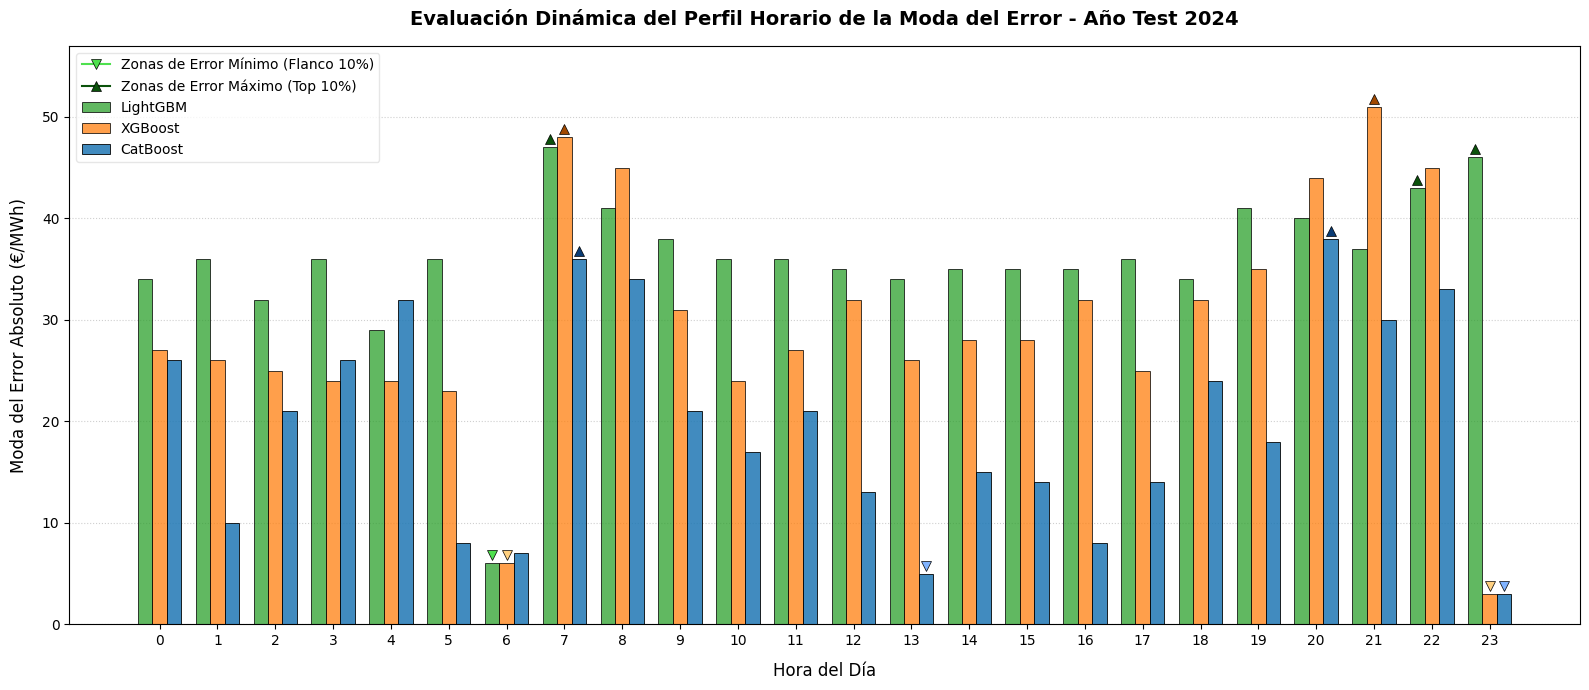

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 8. ANÁLISIS HORARIO COMPARATIVO DEL ERROR (MODA DEL ERROR ABSOLUTO - DESDE CSV)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_2024.csv', index_col=0, parse_dates=True)

# Función interna para calcular la moda del error absoluto redondeado a enteros
def calcular_moda_error(df, col_pred):
    # Calculamos el error absoluto por cada fila
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    # Redondeamos a enteros para permitir que existan valores repetidos (Moda)
    error_redondeado = error_absoluto.round(0)
    # Agrupamos por hora y extraemos el valor más frecuente (la moda)
    return error_redondeado.groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)

# Cálculo dinámico de la moda del error por hora para cada modelo
moda_lgb = calcular_moda_error(df_resultados_csv, 'Prediccion_LightGBM')
moda_xgb = calcular_moda_error(df_resultados_csv, 'Prediccion_XGBoost')
moda_cat = calcular_moda_error(df_resultados_csv, 'Prediccion_CatBoost')

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.25

# 2. Dibujo de las barras base
barras_lgb = ax.bar(horas - ancho_barra, moda_lgb, width=ancho_barra, label='LightGBM', color='#2ca02c', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_xgb = ax.bar(horas, moda_xgb, width=ancho_barra, label='XGBoost', color='#ff7f0e', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_cat = ax.bar(horas + ancho_barra, moda_cat, width=ancho_barra, label='CatBoost', color='#1f77b4', alpha=0.85, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACIÓN Y MARCADO DINÁMICO CON COLORES ASOCIADOS AL MODELO
# ---------------------------------------------------------------------------------------
modelos_data = [
    {
        'valores': moda_lgb, 
        'desplazamiento': -ancho_barra, 
        'color_alto': '#0b520b',      # Verde bosque para el peor LightGBM
        'color_bajo': '#4ee04e'       # Verde claro para el mejor LightGBM
    },
    {
        'valores': moda_xgb, 
        'desplazamiento': 0, 
        'color_alto': '#a14900',      # Marrón teja para el peor XGBoost
        'color_bajo': '#ffd080'       # Naranja claro para el mejor XGBoost
    },
    {
        'valores': moda_cat, 
        'desplazamiento': ancho_barra, 
        'color_alto': '#0a3c75',      # Azul marino para el peor CatBoost
        'color_bajo': '#80b3ff'       # Azul cielo para el mejor CatBoost
    }
]

# Controladores para no duplicar los nombres genéricos en la leyenda
legend_max_added = False
legend_min_added = False

for mod in modelos_data:
    valores = mod['valores']
    desplazamiento = mod['desplazamiento']
    
    max_val = valores.max()
    min_val = valores.min()
    rango_total = max_val - min_val
    
    limite_alto = max_val - (0.10 * rango_total)
    limite_bajo = min_val + (0.10 * rango_total)
    
    for hora in horas:
        valor_actual = valores[hora]
        posicion_x = hora + desplazamiento
        
        # Caso A: Valores máximos o en el 10% superior (Flecha hacia arriba '^')
        if valor_actual >= limite_alto:
            label_text = 'Zonas de Error Máximo (Top 10%)' if not legend_max_added else ""
            ax.plot(posicion_x, valor_actual + 0.8, marker='^', color=mod['color_alto'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_max_added = True
            
        # Caso B: Valores mínimos o en el 10% inferior (Flecha hacia abajo 'v')
        elif valor_actual <= limite_bajo:
            label_text = 'Zonas de Error Mínimo (Flanco 10%)' if not legend_min_added else ""
            ax.plot(posicion_x, valor_actual + 0.8, marker='v', color=mod['color_bajo'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO ACADÉMICO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluación Dinámica del Perfil Horario de la Moda del Error - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Día', fontsize=12, labelpad=10)
ax.set_ylabel('Moda del Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Límites del eje Y holgados para que no se solape con la leyenda
error_max_global = max(moda_lgb.max(), moda_xgb.max(), moda_cat.max())
ax.set_ylim(0, error_max_global + 6)

plt.tight_layout()

# Guardado automático con nuevo nombre descriptivo
plt.savefig('grafico_comparativa_moda_error_horario_3modelos_2024.png', dpi=300)
plt.show()

#### Errores Extremios

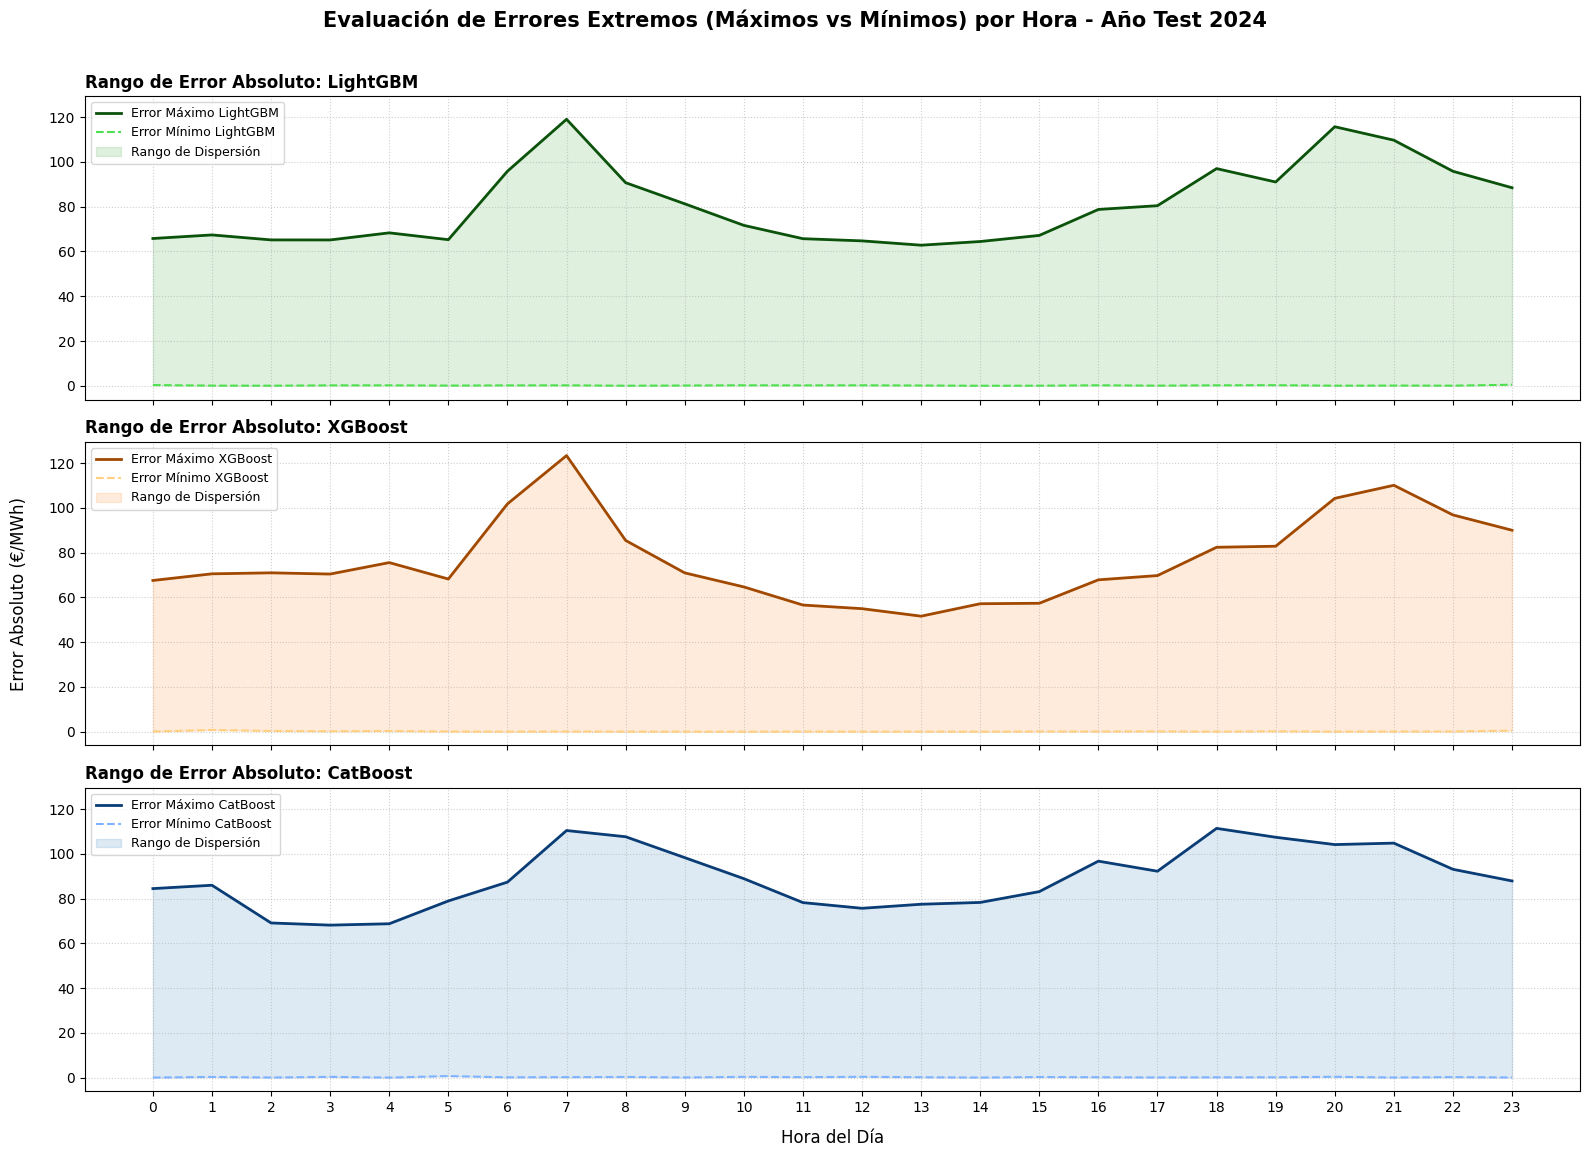

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =======================================================================================
# 9. ANÁLISIS HORARIO DE ERRORES EXTREMOS (MÁXIMOS Y MÍNIMOS DESDE CSV)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_2024.csv', index_col=0, parse_dates=True)

# Función para extraer el error absoluto máximo y mínimo por hora
def calcular_errores_extremos(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    return err_max, err_min

# Cálculo dinámico para cada modelo
max_lgb, min_lgb = calcular_errores_extremos(df_resultados_csv, 'Prediccion_LightGBM')
max_xgb, min_xgb = calcular_errores_extremos(df_resultados_csv, 'Prediccion_XGBoost')
max_cat, min_cat = calcular_errores_extremos(df_resultados_csv, 'Prediccion_CatBoost')

horas = np.arange(24)

# Creamos 3 subgráficas verticales que comparten el mismo eje Y para una comparación justa
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True, sharey=True)

# ---------------------------------------------------------------------------------------
# PANEL 1: LIGHTGBM (Verde)
# ---------------------------------------------------------------------------------------
ax1.plot(horas, max_lgb, color='#0b520b', linestyle='-', linewidth=2, label='Error Máximo LightGBM')
ax1.plot(horas, min_lgb, color='#4ee04e', linestyle='--', linewidth=1.5, label='Error Mínimo LightGBM')
ax1.fill_between(horas, min_lgb, max_lgb, color='#2ca02c', alpha=0.15, label='Rango de Dispersión')
ax1.set_title('Rango de Error Absoluto: LightGBM', fontsize=12, fontweight='bold', loc='left')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=9)

# ---------------------------------------------------------------------------------------
# PANEL 2: XGBOOST (Naranja)
# ---------------------------------------------------------------------------------------
ax2.plot(horas, max_xgb, color='#a14900', linestyle='-', linewidth=2, label='Error Máximo XGBoost')
ax2.plot(horas, min_xgb, color='#ffd080', linestyle='--', linewidth=1.5, label='Error Mínimo XGBoost')
ax2.fill_between(horas, min_xgb, max_xgb, color='#ff7f0e', alpha=0.15, label='Rango de Dispersión')
ax2.set_title('Rango de Error Absoluto: XGBoost', fontsize=12, fontweight='bold', loc='left')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_ylabel('Error Absoluto (€/MWh)', fontsize=12, labelpad=15)

# ---------------------------------------------------------------------------------------
# PANEL 3: CATBOOST (Azul)
# ---------------------------------------------------------------------------------------
ax3.plot(horas, max_cat, color='#0a3c75', linestyle='-', linewidth=2, label='Error Máximo CatBoost')
ax3.plot(horas, min_cat, color='#80b3ff', linestyle='--', linewidth=1.5, label='Error Mínimo CatBoost')
ax3.fill_between(horas, min_cat, max_cat, color='#1f77b4', alpha=0.15, label='Rango de Dispersión')
ax3.set_title('Rango de Error Absoluto: CatBoost', fontsize=12, fontweight='bold', loc='left')
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper left', fontsize=9)
ax3.set_xlabel('Hora del Día', fontsize=12, labelpad=10)

# Configuración de los ejes comunes
plt.xticks(horas)
fig.suptitle('Evaluación de Errores Extremos (Máximos vs Mínimos) por Hora - Año Test 2024', fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardado automático con alta resolución para la memoria
plt.savefig('grafico_errores_extremos_horarios_3modelos_2024.png', dpi=300)
plt.show()


#### Conujunto

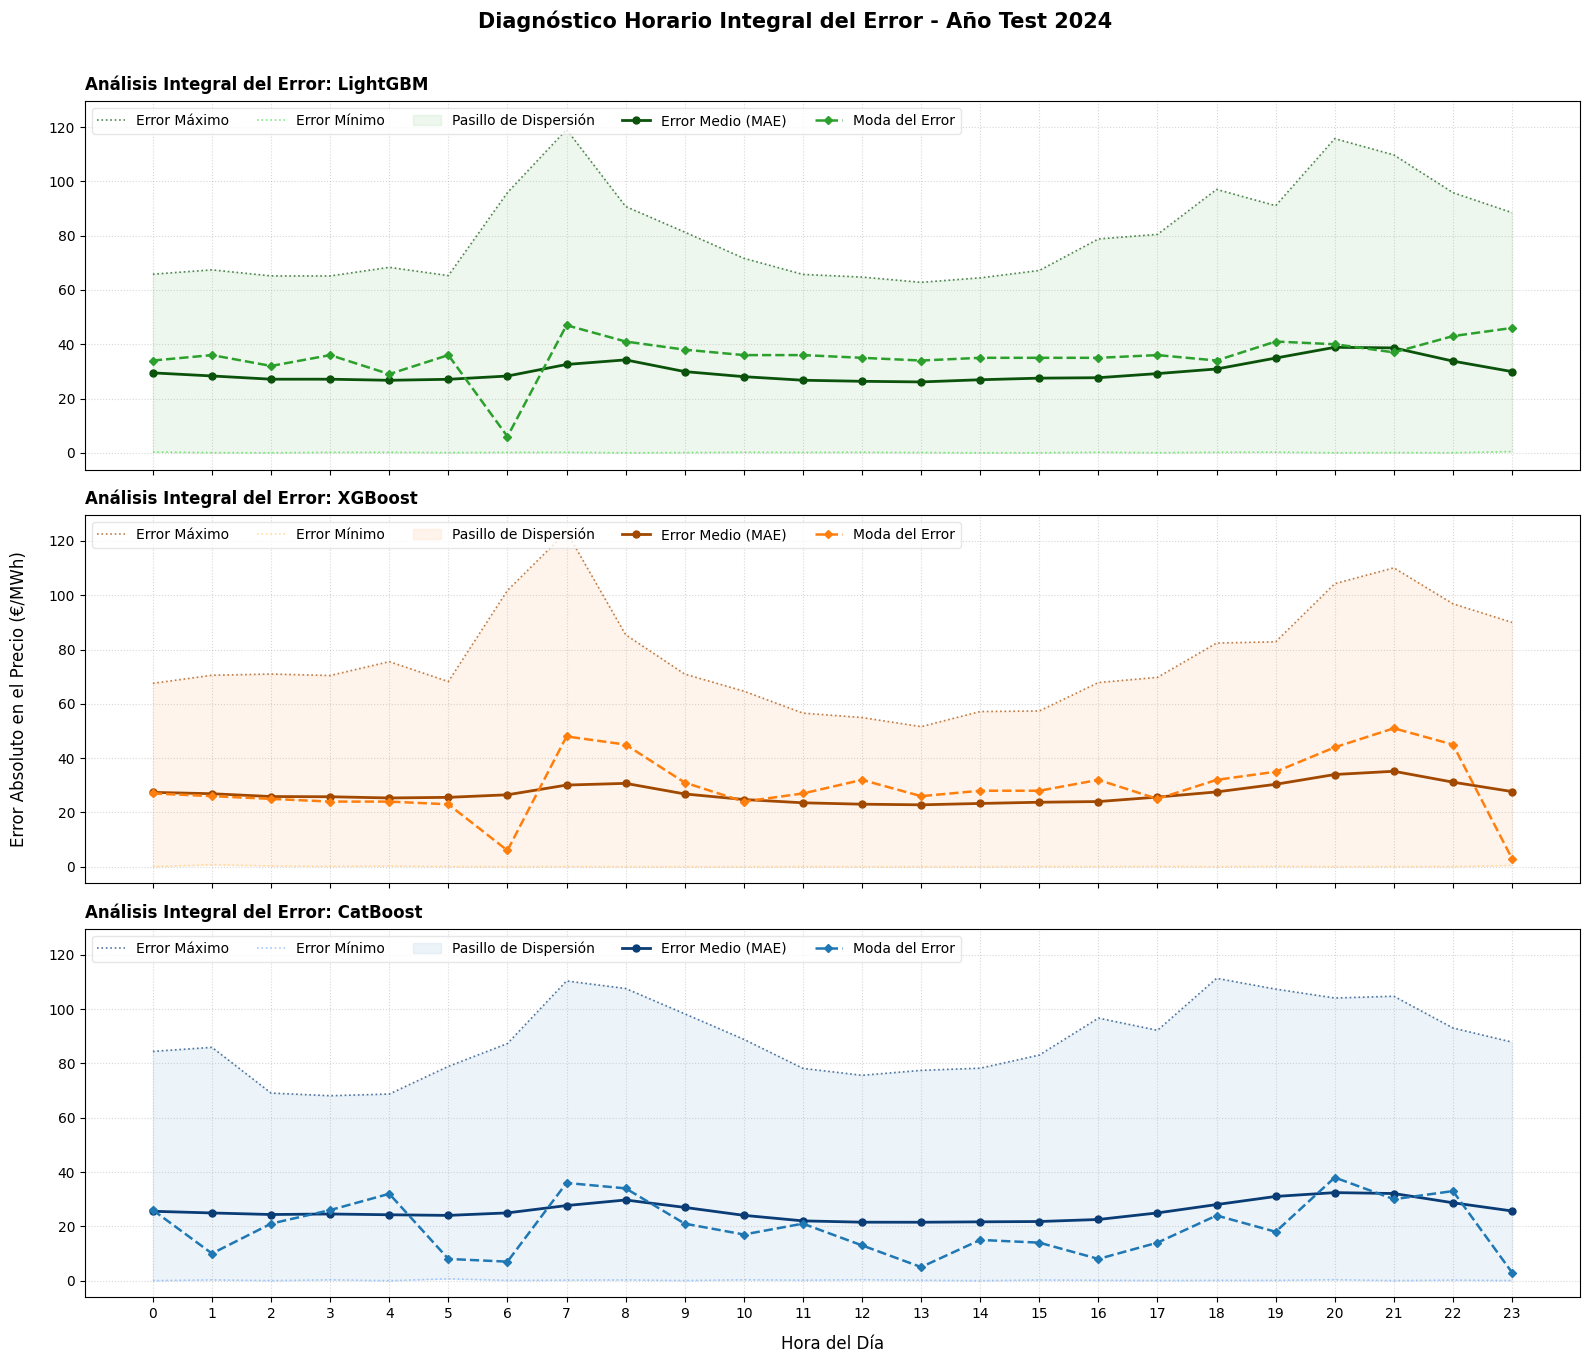

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =======================================================================================
# 10. DIAGNÓSTICO INTEGRAL DEL ERROR: MÁXIMOS, MÍNIMOS, MEDIAS Y MODAS (DESDE CSV)
# =======================================================================================

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_2024.csv', index_col=0, parse_dates=True)

# Función para calcular todas las métricas horarias de forma limpia
def calcular_metricas_completas(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    err_mean = error_absoluto.groupby(df['hour']).mean()
    err_mode = error_absoluto.round(0).groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)
    
    return err_max, err_min, err_mean, err_mode

# Cálculo dinámico para cada uno de los modelos
max_lgb, min_lgb, mean_lgb, mode_lgb = calcular_metricas_completas(df_resultados_csv, 'Prediccion_LightGBM')
max_xgb, min_xgb, mean_xgb, mode_xgb = calcular_metricas_completas(df_resultados_csv, 'Prediccion_XGBoost')
max_cat, min_cat, mean_cat, mode_cat = calcular_metricas_completas(df_resultados_csv, 'Prediccion_CatBoost')

horas = np.arange(24)

# Estructura de 3 paneles verticales que comparten los mismos ejes para comparar de forma justa
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 14), sharex=True, sharey=True)

# Configuración de los datos estructurados para el bucle automatizado
paneles = [
    {
        'ax': ax1, 'titulo': 'Análisis Integral del Error: LightGBM',
        'max': max_lgb, 'min': min_lgb, 'mean': mean_lgb, 'mode': mode_lgb,
        'c_base': '#2ca02c', 'c_oscuro': '#0b520b', 'c_claro': '#4ee04e'
    },
    {
        'ax': ax2, 'titulo': 'Análisis Integral del Error: XGBoost',
        'max': max_xgb, 'min': min_xgb, 'mean': mean_xgb, 'mode': mode_xgb,
        'c_base': '#ff7f0e', 'c_oscuro': '#a14900', 'c_claro': '#ffd080'
    },
    {
        'ax': ax3, 'titulo': 'Análisis Integral del Error: CatBoost',
        'max': max_cat, 'min': min_cat, 'mean': mean_cat, 'mode': mode_cat,
        'c_base': '#1f77b4', 'c_oscuro': '#0a3c75', 'c_claro': '#80b3ff'
    }
]

for p in paneles:
    ax = p['ax']
    
    # A. Dibujar el pasillo de dispersión (Máximos y Mínimos)
    ax.plot(horas, p['max'], color=p['c_oscuro'], linestyle=':', linewidth=1.2, alpha=0.7, label='Error Máximo')
    ax.plot(horas, p['min'], color=p['c_claro'], linestyle=':', linewidth=1.2, alpha=0.7, label='Error Mínimo')
    ax.fill_between(horas, p['min'], p['max'], color=p['c_base'], alpha=0.08, label='Pasillo de Dispersión')
    
    # B. Dibujar el Comportamiento Central (Media y Moda)
    # Media (MAE) con línea discontinua y marcadores redondos
    ax.plot(horas, p['mean'], color=p['c_oscuro'], linestyle='-', linewidth=2, 
            marker='o', markersize=5, label='Error Medio (MAE)')
    
    # Moda con línea de guiones y marcadores de diamante
    ax.plot(horas, p['mode'], color=p['c_base'], linestyle='--', linewidth=1.8, 
            marker='D', markersize=4, label='Moda del Error')
    
    # C. Estética y formatos por panel
    ax.set_title(p['titulo'], fontsize=12, fontweight='bold', loc='left', pad=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper left', fontsize=10, ncol=5, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Títulos de los ejes globales
ax2.set_ylabel('Error Absoluto en el Precio (€/MWh)', fontsize=12, labelpad=15)
ax3.set_xlabel('Hora del Día', fontsize=12, labelpad=10)

plt.xticks(horas)
fig.suptitle('Diagnóstico Horario Integral del Error - Año Test 2024', fontsize=15, fontweight='bold', y=0.97)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardado automático en alta calidad para el documento del TFG
plt.savefig('grafico_diagnostico_integral_errores_2024.png', dpi=300)
plt.show()
